In [12]:
# 必要なライブラリのimport
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns

sns.set_theme()

In [13]:
prep_data = pd.read_csv('iowa_ames_housing_revised.csv')

prep_data.head()

,Order,area,price,OverallQual,OverallCond,YearBuilt,BsmtFinSF1,X1stFlrSF,X2ndFlrSF
0,1,1710,208500,7,5,2003,706,856,854
1,2,1262,181500,6,8,1976,978,1262,0
2,3,1786,223500,7,5,2001,486,920,866
3,4,1717,140000,7,5,1915,216,961,756
4,5,2198,250000,8,5,2000,655,1145,1053


In [14]:
prep_data.tail()

,Order,area,price,OverallQual,OverallCond,YearBuilt,BsmtFinSF1,X1stFlrSF,X2ndFlrSF
1455,1456,1647,175000,6,5,1999,0,953,694
1456,1457,2073,210000,6,6,1978,790,2073,0
1457,1458,2340,266500,7,9,1941,275,1188,1152
1458,1459,1078,142125,5,6,1950,49,1078,0
1459,1460,1256,147500,5,6,1965,830,1256,0


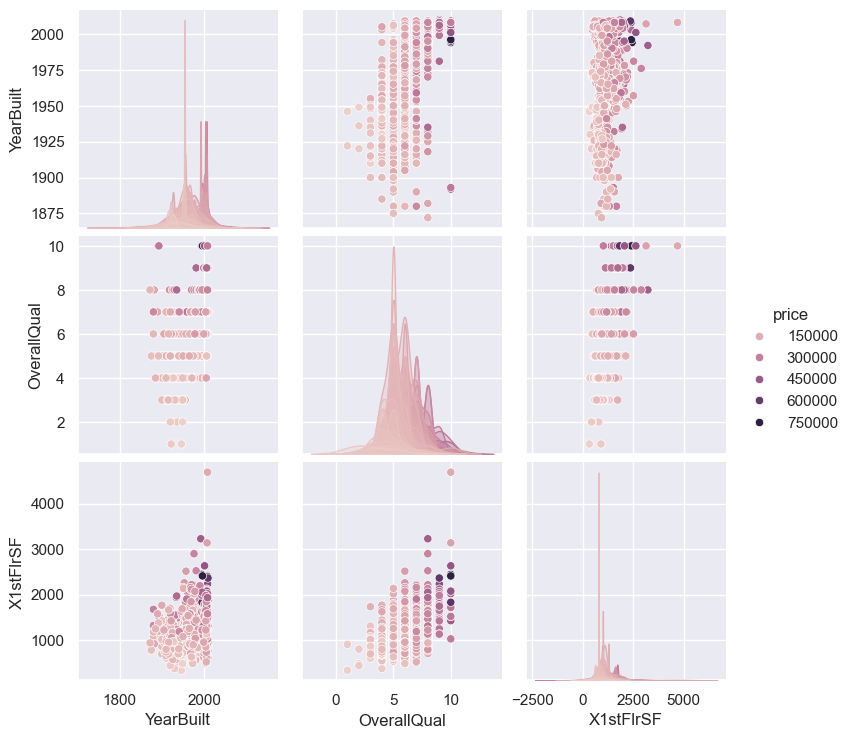

In [19]:
data = prep_data[['price','YearBuilt','OverallQual','X1stFlrSF']]

# ペアプロットを描画
sns.pairplot(data, hue='price')

In [20]:
# 最小二乗法の実施（説明変数：YearBuiltのみ）
model1 = smf.ols(formula='price ~ YearBuilt', data=data).fit()

# 最小二乗法の実施（説明変数：OverallQual と X1stFlrSF）
model2 = smf.ols(formula='price ~ OverallQual+X1stFlrSF', data=data).fit()

# 最小二乗法の実施（説明変数：Yearbuilt　と　OverallQualと X1stFlrSF）
model3 = smf.ols(formula='price ~ YearBuilt+OverallQual+X1stFlrSF', data=data).fit()

In [21]:
# AICを計算する
print('Model-1:',model1.aic)
print('Model-2:',model2.aic)
print('Model-3:',model3.aic)

Model-1: 36625.70646748859
Model-2: 35367.18730733775
Model-3: 35336.629042057226


Model-3が最小。

In [22]:
# AICが最小のmodel3の詳細を表示
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     1134.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:53:12   Log-Likelihood:                -17664.
No. Observations:                1460   AIC:                         3.534e+04
Df Residuals:                    1456   BIC:                         3.536e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -6.172e+05   8.74e+04     -7.065      